# Tutorial 04 · From pixels to a classifier
**STAT / SDST 3612 · Image classification with stochastic gradient descent**

## Overview
Build a classifier for handwritten 3s and 8s, then use its mistakes to decide what to
improve. Logistic regression keeps the complete learning process visible: pixels become
a score, the score becomes a probability, and a loss supplies a signal for learning.

**The route through the tutorial:**
1. Define the examples, labels and input representation (§1–2).
2. Connect predictions to a loss and one gradient update (§3–4).
3. Train, inspect errors, compare a change and select a model (§5–7).
4. Reconsider the model's assumptions through alternative classifiers, XOR and convolution (§8).

**Learning objectives.** By the end, you should be able to:
- Represent images as arrays and explain the roles of training, validation and test data.
- Connect prediction, cross-entropy and a gradient update; explain the signs in one update.
- Run and modify minibatch SGD, reasoning about input scale, learning rate and batch size.
- Design a validation comparison, justify a model choice and interpret its test result.
- Explain a linear model's limitations and what nonlinear features or convolution could add.

**Before you start:** basic Python and NumPy arrays, matrix multiplication and the idea
of a derivative. No previous image-classifier implementation is needed.

The baseline runs from top to bottom. Then revisit the experiment cells and change
one decision at a time. The important functions are visible and editable below;
they come from the same Python source that powers the interactive website.

On the website, each chapter connects **Understand → Explore → Read the Python → Try it
yourself**. The one-step chapter also replays the actual Python execution, showing each
line's intermediate values. Use that view to explain the signs before completing §4 here.

**Your deliverable:** a baseline, one motivated change, a fair comparison, and a short
explanation of the result and its limits. Better accuracy is not a requirement.
AI assistance is welcome; explain your decisions and verify the resulting work.

Extract the student package, install with `pip install -r requirements.txt`, then open
this notebook with Jupyter. Data and helper code are supplied; the notebook makes no
downloads. MNIST: handwritten digits collected by LeCun and colleagues.

## 1 · Meet the data
One image is a 28 × 28 array; one row of the design matrix has 784 values.
Labels are **0 = digit 3**, **1 = digit 8**. Flattening is reversible: order is preserved.

train 960 images; counts [3, 8]: [480 480]
validation 240 images; counts [3, 8]: [120 120]
test 800 images; counts [3, 8]: [400 400]


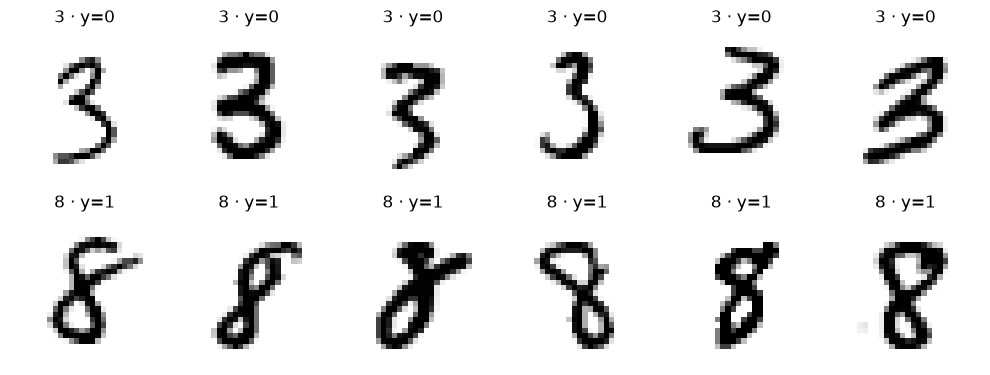

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

# Repository root, notebook directory, or extracted student package.
roots = [Path.cwd(), Path.cwd() / 'src/tutorials/tutorial04']
ROOT = next(p for p in roots if (p / 'experiment.py').exists())
sys.path.insert(0, str(ROOT))
from experiment import load_data, transform, features

data = load_data(ROOT / 'data/mnist_3v8.npz')
images, labels = data['images'], data['labels']
for split in ('train', 'validation', 'test'):
    ids = data[split]
    print(split, len(ids), 'images; counts [3, 8]:', np.bincount(labels[ids].astype(int)))

fig, axes = plt.subplots(2, 6, figsize=(10, 4))
for label, row in zip((0, 1), axes):
    ids = data['train'][labels[data['train']] == label][:6]
    for ax, i in zip(row, ids):
        ax.imshow(images[i], cmap='gray_r', vmin=0, vmax=1)
        ax.set_title(f"{'8' if label else '3'} · y={label}")
        ax.axis('off')
plt.tight_layout()
plt.show()

**Three sets, three jobs.** The 960 training examples update parameters. The 240 validation
examples help choose settings. Keep the original 800 test examples untouched until
you have chosen a model. Splits are balanced and fixed with seed 3612.

**Think:** if images and labels were shuffled independently, would training still
be meaningful? Explain before moving on.

## 2 · Prepare the inputs
Scaling changes numerical units. A representation changes the features. Augmentation
adds labelled training examples. These are separate decisions.

The loader scales intensities from 0–255 to 0–1. Compare an image with its blurred,
edge, and shifted versions. Which operations might remove useful information?

Original (28, 28) range: 0.0 1.0
Blur (28, 28) range: 0.0 0.9181153797338505
Edges (28, 28) range: 0.0 1.0887430364699218
Shift right (28, 28) range: 0.0 1.0


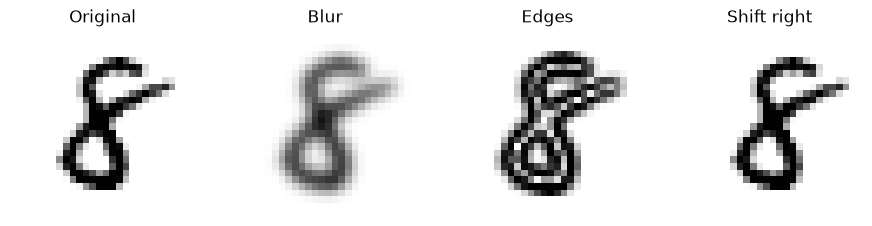

X_train: (960, 784) y_train: (960,)


In [2]:
i = int(data['train'][0])
operations = [('Original', 'raw'), ('Blur', 'blur'), ('Edges', 'edges'), ('Shift right', 'shift')]
fig, axes = plt.subplots(1, 4, figsize=(11, 3))
for ax, (name, operation) in zip(axes, operations):
    out = transform(images[i], operation, 1)
    ax.imshow(out, cmap='gray_r', vmin=0, vmax=1)
    ax.set_title(name)
    ax.axis('off')
    print(name, out.shape, 'range:', out.min(), out.max())
plt.show()

X_train = features(images[data['train']])
y_train = labels[data['train']]
X_val = features(images[data['validation']])
y_val = labels[data['validation']]
print('X_train:', X_train.shape, 'y_train:', y_train.shape)

## 3 · Make a prediction and define a loss
Compute $z = Xw + b$, then $p = \sigma(z)$. Classify as 8 when $p \geq 0.5$.

Cross-entropy distinguishes two correct predictions with different confidence:
$\ell = -y\log(p) - (1-y)\log(1-p)$.
The implementation below evaluates the same loss stably from scores.

In [3]:
def sigmoid(z):
    z = np.asarray(z, dtype=np.float64)
    e = np.exp(-np.abs(z))
    return np.where(z >= 0, 1 / (1 + e), e / (1 + e))

def loss(w, b, X, y):
    z = X @ w + b
    return float(np.mean(np.logaddexp(0.0, z) - y * z))

In [4]:
w, b = np.zeros(X_train.shape[1]), 0.0
print('First five probabilities:', sigmoid(X_train[:5] @ w + b))
print('Initial mean loss:', loss(w, b, X_train, y_train))
for p in (.01, .4, .51, .99):
    print(f'p(8)={p:.2f}; loss if true 8={-np.log(p):.3f}; prediction={8 if p >= .5 else 3}')

First five probabilities: [0.5 0.5 0.5 0.5 0.5]
Initial mean loss: 0.6931471805599453
p(8)=0.01; loss if true 8=4.605; prediction=3
p(8)=0.40; loss if true 8=0.916; prediction=3
p(8)=0.51; loss if true 8=0.673; prediction=8
p(8)=0.99; loss if true 8=0.010; prediction=8


## 4 · Learn from one example
The residual is $p-y$. For one image, the weight gradient is $(p-y)x$.
Subtract learning rate × gradient. For a batch, average across its examples.

**Before running:** choose a true 8. Starting at $p=0.5$, predict the signs of the
residual and the change to a weight on an inked pixel. Explain the two signs.

In [5]:
def gradient(w, b, X, y):
    residual = sigmoid(X @ w + b) - y
    return X.T @ residual / len(y), float(residual.mean())

def step(w, b, X, y, lr):
    z = X @ w + b
    p = sigmoid(z)
    residual = p - y
    dw = X.T @ residual / len(y)
    db = float(residual.mean())
    w_new = w - lr * dw
    b_new = b - lr * db
    return w_new, b_new

In [6]:
index = int(np.flatnonzero(y_train == 1)[0])  # Try a true 3 afterwards.
X_one, y_one = X_train[index:index+1], y_train[index:index+1]
eta = 0.1
w0, b0 = np.zeros(X_train.shape[1]), 0.0
w1, b1 = step(w0, b0, X_one, y_one, eta)
print('p(8):', sigmoid(X_one @ w0 + b0), '->', sigmoid(X_one @ w1 + b1))
print('loss:', loss(w0, b0, X_one, y_one), '->', loss(w1, b1, X_one, y_one))
print('bias:', b0, '->', b1)

p(8): [0.5] -> [0.9877327]
loss: 0.6931471805599453 -> 0.01234316104992672
bias: 0.0 -> 0.05


**Try it:** change the example and learning rate. Explain what you observe.
This is improvement on one example, not evidence of good generalisation.

### Connect the update to the chain rule
For one example, $z=\mathbf{w}^\top\mathbf{x}+b$ and $p=\sigma(z)$.
Cross-entropy and the sigmoid combine to give

$$\frac{\partial\ell}{\partial z}=p-y,\qquad
\frac{\partial\ell}{\partial w_j}=(p-y)x_j,\qquad
\frac{\partial\ell}{\partial b}=p-y.$$

On an inked pixel of a true 8, starting at $p=0.5$, the gradient is negative.
Subtracting that gradient increases the weight. On a blank pixel, it is zero.
The minibatch gradient averages these contributions, rather than multiplying the
effective learning rate by the batch size. A stochastic update need not reduce
the loss on the whole training set at every step.

## 5 · Build the training loop
An epoch is a pass over the training data. Every epoch reshuffles examples using a
seeded generator. A minibatch supplies an average gradient for one update.

**Why batches?** A full-data gradient reads every example before each update. A small
batch gives a cheaper, noisier estimate and allows more frequent updates. Batch size 1
is stochastic gradient descent; small groups give minibatch SGD; the full set gives
batch gradient descent.

Validation measures progress without updating weights. Equal epochs do not mean
equal numbers of updates when batch size or training-set size changes.

In [7]:
def metrics(w, b, X, y):
    p = sigmoid(X @ w + b)
    pred = p >= .5
    confusion = [[int(np.sum((y == actual) & (pred == guess)))
                  for guess in (0, 1)] for actual in (0, 1)]
    return {'loss': loss(w, b, X, y), 'accuracy': float(np.mean(pred == y)),
            'confusion': confusion}

def train_epochs(X, y, X_validation, y_validation, *, lr=.1, epochs=25,
                 batch=32, seed=3612):
    """Yield one checkpoint per epoch, including the untrained starting point.

    Each epoch uses a seeded random permutation. Validation never changes weights.
    Equal epochs mean equal passes through data, not equal numbers of updates.
    """
    w, b = np.zeros(X.shape[1]), 0.0
    rng = np.random.default_rng(seed)
    for epoch in range(epochs + 1):
        yield {'epoch': epoch, 'train': metrics(w, b, X, y),
               'validation': metrics(w, b, X_validation, y_validation),
               'w': w.copy(), 'b': float(b)}
        if epoch == epochs:
            break
        order = rng.permutation(len(y))
        for start in range(0, len(y), batch):
            indices = order[start:start + batch]
            w, b = step(w, b, X[indices], y[indices], lr)

def train(X, y, X_validation, y_validation, **settings):
    history, final = [], None
    for checkpoint in train_epochs(X, y, X_validation, y_validation, **settings):
        final = checkpoint
        history.append({k: checkpoint[k] for k in ('epoch', 'train', 'validation')})
    return {'w': final['w'], 'b': final['b'], 'history': history}

Training: {'loss': 0.07137347026881583, 'accuracy': 0.9770833333333333, 'confusion': [[466, 14], [8, 472]]}
Validation: {'loss': 0.1377722307592762, 'accuracy': 0.9541666666666667, 'confusion': [[113, 7], [4, 116]]}


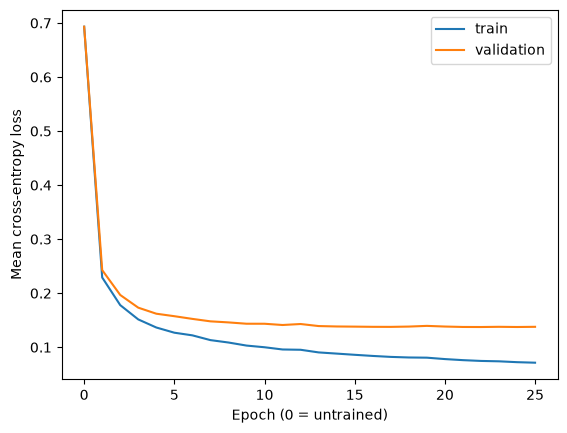

In [8]:
settings = dict(lr=0.1, epochs=25, batch=32, seed=3612)
baseline = train(X_train, y_train, X_val, y_val, **settings)
print('Training:', baseline['history'][-1]['train'])
print('Validation:', baseline['history'][-1]['validation'])

def plot_history(model):
    for split in ('train', 'validation'):
        plt.plot([r['epoch'] for r in model['history']],
                 [r[split]['loss'] for r in model['history']], label=split)
    plt.xlabel('Epoch (0 = untrained)')
    plt.ylabel('Mean cross-entropy loss')
    plt.legend()
    plt.show()

plot_history(baseline)

**First comparison:** predict what happens with a smaller learning rate, then change
only `lr` below. Keep the baseline so the comparison remains visible.
Observe both validation loss and accuracy; neither needs to improve at every epoch.

baseline validation accuracy: 0.9541666666666667 loss: 0.1377722307592762
smaller learning rate validation accuracy: 0.95 loss: 0.18437654134846285


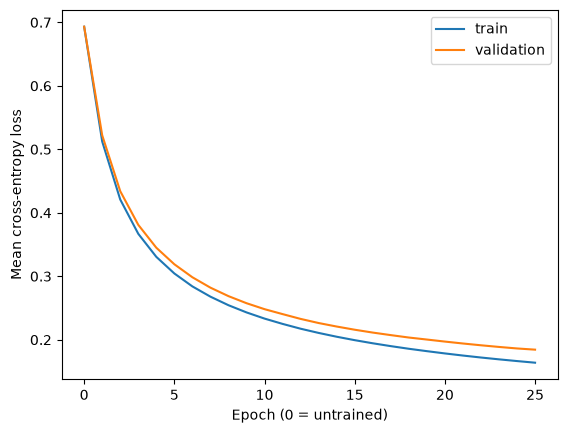

In [9]:
alternative_settings = {**settings, 'lr': 0.01}
alternative = train(X_train, y_train, X_val, y_val, **alternative_settings)
for name, model in [('baseline', baseline), ('smaller learning rate', alternative)]:
    result = model['history'][-1]['validation']
    print(name, 'validation accuracy:', result['accuracy'], 'loss:', result['loss'])
plot_history(alternative)

## 6 · Inspect mistakes and investigate a change
A single accuracy hides individual examples. Inspect validation errors before proposing
an improvement. The confusion matrix has actual labels in rows, predictions in columns.

Confusion matrix [3, 8]: [[113, 7], [4, 116]]


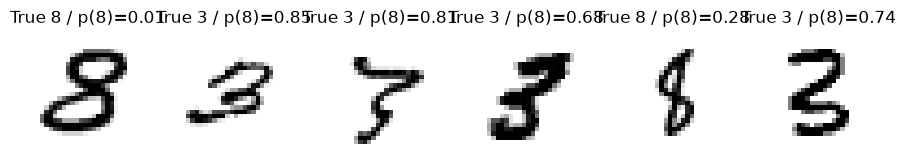

Original validation: 0.9541666666666667
Shifted validation: 0.9333333333333333


In [10]:
p_val = sigmoid(X_val @ baseline['w'] + baseline['b'])
wrong = np.flatnonzero((p_val >= 0.5) != y_val)
print('Confusion matrix [3, 8]:', metrics(baseline['w'], baseline['b'], X_val, y_val)['confusion'])
fig, axes = plt.subplots(1, 6, figsize=(11, 3))
for ax in axes:
    ax.axis('off')
for ax, j in zip(axes, wrong[:6]):
    ax.imshow(images[data['validation'][j]], cmap='gray_r', vmin=0, vmax=1)
    ax.set_title(f"True {8 if y_val[j] else 3} / p(8)={p_val[j]:.2f}")
plt.show()

shifted_val = features(transform(images[data['validation']], 'shift', 1))
print('Original validation:', metrics(baseline['w'], baseline['b'], X_val, y_val)['accuracy'])
print('Shifted validation:', metrics(baseline['w'], baseline['b'], shifted_val, y_val)['accuracy'])

### Your experiment
Choose **one** change: a learning rate, a representation, or shifted training examples.
Before running, replace the text below with your own reasoning.

- My proposed change:
- Why it might help:
- What I will keep fixed:
- Which observation would count against my expectation:

The next cell supplies a runnable augmentation example. Adapt it or replace it.
Augmentation doubles the examples, so equal epochs also mean roughly twice as many
updates. Consider this when attributing any improvement to augmentation.

In [11]:
augmented_images = np.concatenate([
    images[data['train']], transform(images[data['train']], 'shift', 1)
])
augmented_y = np.concatenate([y_train, y_train])
candidate = train(features(augmented_images), augmented_y, X_val, y_val, **settings)
for name, model in [('baseline', baseline), ('candidate', candidate)]:
    for condition, X_eval in [('original', X_val), ('shifted', shifted_val)]:
        result = metrics(model['w'], model['b'], X_eval, y_val)
        print(name, condition, 'validation accuracy:', result['accuracy'])

baseline original validation accuracy: 0.9541666666666667
baseline shifted validation accuracy: 0.9333333333333333
candidate original validation accuracy: 0.95
candidate shifted validation accuracy: 0.95


**Interpret your result:** What changed? Did your prediction hold? What remains
uncertain? One direction of translation does not establish invariance to all translations.

If you change preprocessing, train on those features and apply the **same transformation**
to validation and test images.

## 7 · Choose a model, then evaluate once on test data
Choose using validation results. Write your reason before enabling the final cell.
Do not use repeated test evaluations to choose hyperparameters.

In [12]:
chosen = baseline             # Change after comparing validation results.
chosen_representation = 'raw'
chosen_normalize = True
reason = ''                   # Explain your choice before the final evaluation.

if reason.strip():
    X_test = features(images[data['test']], chosen_representation, chosen_normalize)
    y_test = labels[data['test']]
    print('My decision:', reason)
    print('Final test results:', metrics(chosen['w'], chosen['b'], X_test, y_test))
else:
    print('Test set remains untouched. Write your model-selection reason to evaluate.')

Test set remains untouched. Write your model-selection reason to evaluate.


## 8 · Beyond the baseline: which assumption would you change?
Logistic regression is a transparent baseline, not a requirement for image classification.
Separate **the classifier**, **its input representation**, and **the method used to fit it**.
Replacing SGD alone cannot give a linear classifier a nonlinear decision boundary.

### A different baseline, without SGD
Nearest-centroid classification predicts the class whose training mean is closest to the
input. It needs no iterative optimisation. Under Euclidean distance its two-class decision
boundary is still linear, so this alternative alone does not solve every representation problem.
Compare it on the same validation split; do not choose methods using the test set.

In [13]:
centres = np.stack([X_train[y_train == c].mean(axis=0) for c in (0, 1)])
distance = ((X_val[:, None, :] - centres[None, :, :]) ** 2).sum(axis=2)
centroid_prediction = distance.argmin(axis=1)
print('Nearest-centroid validation accuracy:', (centroid_prediction == y_val).mean())
print('Logistic baseline validation accuracy:', baseline['history'][-1]['validation']['accuracy'])

Nearest-centroid validation accuracy: 0.8916666666666667
Logistic baseline validation accuracy: 0.9541666666666667


### A limitation you cannot fix by training longer
In XOR, positive examples occupy opposite corners. No line separates all four targets.
An interaction feature $x_1x_2$ makes separation possible in the expanded feature space.
Two ReLU hidden units can also construct suitable features. The weights below are hand-built
to expose the mechanism; they are **not** the result of training a neural network.

In [14]:
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y_xor = np.array([0, 1, 1, 0])
z_linear = 4 * (X_xor[:, 0] + X_xor[:, 1] - .5)
z_interaction = 4 * (X_xor[:, 0] + X_xor[:, 1] - 2 * X_xor[:, 0] * X_xor[:, 1] - .5)
h1 = np.maximum(0, X_xor[:, 0] - X_xor[:, 1])
h2 = np.maximum(0, X_xor[:, 1] - X_xor[:, 0])
z_hidden = 4 * (h1 + h2 - .5)
for name, z in [('linear', z_linear), ('interaction', z_interaction), ('hidden units', z_hidden)]:
    print(name, 'predictions:', (z >= 0).astype(int), 'accuracy:', ((z >= 0) == y_xor).mean())

linear predictions: [0 1 1 1] accuracy: 0.75
interaction predictions: [0 1 1 0] accuracy: 1.0
hidden units predictions: [0 1 1 0] accuracy: 1.0


### What convolution changes
A convolutional layer applies the same local filter at every spatial location. This
introduces **locality and weight sharing**. Move the 3 × 3 window in the website to connect
one multiply-and-sum with one entry of the feature map.

$$a_{r,c}=\sum_{u=0}^{2}\sum_{v=0}^{2}K_{u,v}x_{r+u,c+v}.$$

This is valid cross-correlation, commonly called convolution in deep-learning APIs.
There is no padding or stride greater than one here. A CNN learns its filters; our
fixed example isolates the operation. A feature map is not yet a classification.

In [15]:
def convolution_map(image, kernel):
    """Valid, stride-one cross-correlation: the operation called convolution in CNNs."""
    image, kernel = np.asarray(image), np.asarray(kernel)
    patches = np.lib.stride_tricks.sliding_window_view(image, kernel.shape)
    return np.einsum('ijab,ab->ij', patches, kernel)

Map shape: (26, 26)
One output: 2.9176470588235297
Same patch calculation: 2.9176470588235297


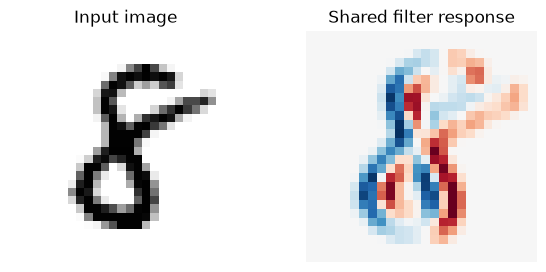

In [16]:
image = images[data['train'][0]]
kernel = np.array([[-1., 0., 1.], [-1., 0., 1.], [-1., 0., 1.]])
feature_map = convolution_map(image, kernel)
r, c = 10, 10
print('Map shape:', feature_map.shape)
print('One output:', feature_map[r, c])
print('Same patch calculation:', (image[r:r+3, c:c+3] * kernel).sum())
fig, axes = plt.subplots(1, 2, figsize=(7, 3))
axes[0].imshow(image, cmap='gray_r', vmin=0, vmax=1)
axes[0].set_title('Input image')
limit = max(abs(feature_map.min()), abs(feature_map.max()))
axes[1].imshow(feature_map, cmap='RdBu', vmin=-limit, vmax=limit)
axes[1].set_title('Shared filter response')
for ax in axes:
    ax.axis('off')
plt.show()

**A next investigation, not a guaranteed upgrade.** Compare this baseline with a small
MLP and a small CNN using the same splits. Choose settings on validation data. Measure
original and shifted accuracy, number of parameters and training cost. What outcome
would make you keep the simpler model?

Convolution is translation-equivariant away from boundary effects: a shifted input
produces a shifted feature map. It is not automatically an invariant classifier.
Pooling, padding, stride and the classification head all affect the final behaviour.

Continue with [CS231n's convolutional networks chapter](https://cs231n.github.io/convolutional-networks/)
or [PyTorch's complete learning workflow](https://docs.pytorch.org/tutorials/beginner/basics/intro.html).

## What to submit
Your executed notebook, including:

1. Your prediction and explanation for one parameter update.
2. A baseline and one motivated experiment with comparable validation results.
3. Your model choice, final test result, and a limitation of your conclusion.

You may use AI to implement an idea or debug an error. Describe your own decisions
and how you checked that the experiment answered your question.